In [1]:
# Importing libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import shap
import joblib
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# 📅 Set time range
start_date = "2004-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

In [3]:
# 📥 Downloading S&P 500 data
sp500 = yf.download("^GSPC", start=start_date, end=end_date, interval='1wk')
sp500.reset_index(inplace=True)
sp500 = sp500[["Date", "Close", "Volume"]]
sp500["Date"] = pd.to_datetime(sp500["Date"]) + pd.offsets.Week(weekday=4)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
# 📥 Downloading VIX data
vix = yf.download("^VIX", start=start_date, end=end_date, interval='1wk')
vix.reset_index(inplace=True)
vix = vix[["Date", "Close"]].rename(columns={"Close": "VIX_Close"})
vix["Date"] = pd.to_datetime(vix["Date"]) + pd.offsets.Week(weekday=4)

[*********************100%***********************]  1 of 1 completed


In [5]:
# Loading unmpemployment rate data
unrate = pd.read_csv("C:/Users/melny/OneDrive/Desktop/statistical analysis/UNRATE.csv")
unrate.columns = ["Date", "Unemployment"]
unrate["Date"] = pd.to_datetime(unrate["Date"])
unrate["Unemployment"] = pd.to_numeric(unrate["Unemployment"], errors='coerce')
unrate = unrate.set_index("Date").resample("W-FRI").ffill().reset_index()

In [6]:
# Loading Google Trends Data
google_sentiment = pd.read_csv("C:/Users/melny/OneDrive/Desktop/statistical analysis/multiTimeline.csv", skiprows=1)
google_sentiment.columns = ["Date", "Google_Sentiment_Index"]
google_sentiment["Date"] = pd.to_datetime(google_sentiment["Date"])
google_sentiment = google_sentiment.set_index("Date").resample("W-FRI").ffill().reset_index()

In [7]:
# 🔗 Merge all datasets
df = sp500.merge(vix, on="Date", how="outer")
# 🧼 Flatten column levels if merged DataFrame has multi-index columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [' '.join(col).strip() for col in df.columns.values]

df = df.merge(unrate, on="Date", how="outer")
df = df.merge(google_sentiment, on="Date", how="left")

In [8]:
# 🧼 Clean and compute features
# Rename columns to standard names
df = df.rename(columns={
    "Close ^GSPC": "Close",
    "Volume ^GSPC": "Volume",
    "VIX_Close ^VIX": "VIX_Close"
})

df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["Close", "VIX_Close", "Unemployment"])

In [9]:
# Calculate returns and changes
df["SP500_Returns"] = df["Close"].pct_change()
df["VIX_Change"] = df["VIX_Close"].pct_change()

In [10]:
# Define mood index function
def get_mood_index(df, vix_col='VIX_Close', google_col='Google_Sentiment_Index', unemp_col='Unemployment'):
    scaler = MinMaxScaler()
    norm_values = scaler.fit_transform(df[[vix_col, google_col, unemp_col]])
    norm_df = pd.DataFrame(norm_values, columns=["VIX_Norm", "Google_Norm", "Unemp_Norm"])
    norm_df.index = df.index
    df = df.copy()
    df[["VIX_Norm", "Google_Norm", "Unemp_Norm"]] = norm_df
    df["Mood_Index"] = df[["VIX_Norm", "Google_Norm", "Unemp_Norm"]].mean(axis=1)
    df["Mood_Zone"] = df["Mood_Index"].apply(lambda val: "Calm" if val < 0.4 else "Cautious" if val < 0.7 else "Panic")
    return df

In [11]:
# Apply mood index
df = get_mood_index(df)

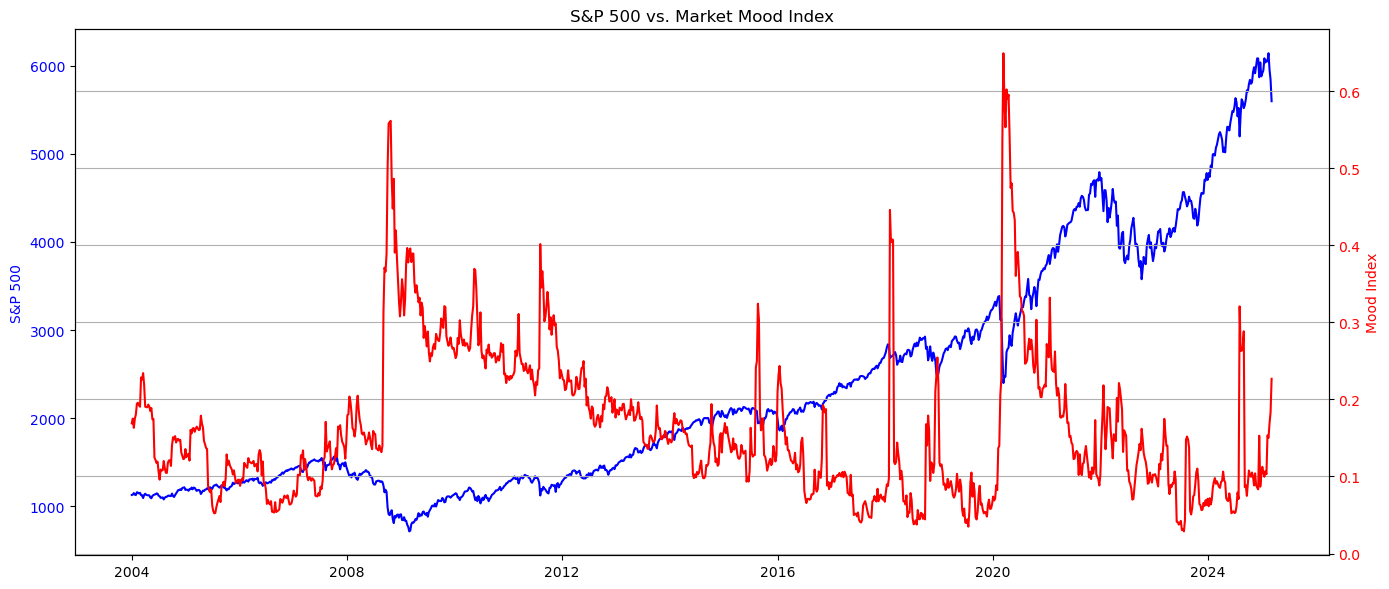

In [12]:
# 📈 Mood Index vs. S&P 500
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df["Date"], df["Close"], color='blue', label="S&P 500")
ax1.set_ylabel("S&P 500", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Mood_Index"], color='red', label="Mood Index")
ax2.set_ylabel("Mood Index", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("S&P 500 vs. Market Mood Index")
fig.tight_layout()
plt.grid(True)
plt.show()


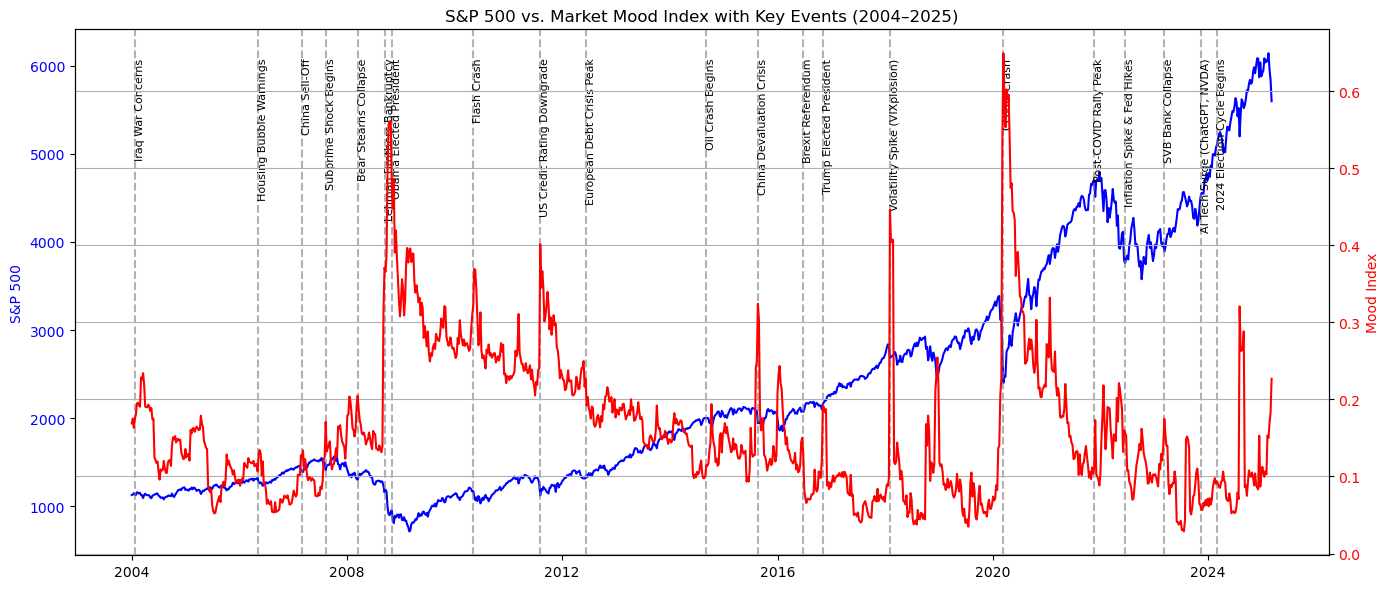

In [13]:
# 📌 Annotated S&P 500 vs Mood Index with Key Market Events 
fig, ax1 = plt.subplots(figsize=(14, 6))

# Line 1: S&P 500
ax1.plot(df["Date"], df["Close"], color='blue', label="S&P 500")
ax1.set_ylabel("S&P 500", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line 2: Mood Index
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Mood_Index"], color='red', label="Mood Index")
ax2.set_ylabel("Mood Index", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# ✅ Annotated Historical Events (2004–2025)
annotations = {
    "Iraq War Concerns": "2004-01-23",
    "Housing Bubble Warnings": "2006-05-10",
    "China Sell-Off": "2007-02-27",
    "Subprime Shock Begins": "2007-08-09",
    "Bear Stearns Collapse": "2008-03-17",
    "Lehman Brothers Bankruptcy": "2008-09-15",
    "Obama Elected President": "2008-11-04",
    "Flash Crash": "2010-05-06",
    "US Credit Rating Downgrade": "2011-08-05",
    "European Debt Crisis Peak": "2012-06-11",
    "Oil Crash Begins": "2014-09-01",
    "China Devaluation Crisis": "2015-08-24",
    "Brexit Referendum": "2016-06-24",
    "Trump Elected President": "2016-11-08",
    "Volatility Spike (VIXplosion)": "2018-02-05",
    "COVID Crash": "2020-03-13",
    "Post-COVID Rally Peak": "2021-11-19",
    "Inflation Spike & Fed Hikes": "2022-06-17",
    "SVB Bank Collapse": "2023-03-10",
    "AI Tech Surge (ChatGPT, NVDA)": "2023-11-15",
    "2024 Election Cycle Begins": "2024-03-01"
}

# Add vertical lines and labels
for label, date in annotations.items():
    ax1.axvline(pd.to_datetime(date), color='gray', linestyle='--', alpha=0.6)
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[1]*0.95, label, rotation=90,
             verticalalignment='top', color='black', fontsize=8)

# Highlight "Panic" zones from Mood Index
panic_dates = df[df["Mood_Zone"] == "Panic"]["Date"]
for pdx in panic_dates:
    ax2.axvline(pdx, color='red', linestyle=':', alpha=0.2)

plt.title("S&P 500 vs. Market Mood Index with Key Events (2004–2025)")
fig.tight_layout()
plt.grid(True)
plt.show()


In [14]:
# ➕ Add Lag Features
df["Mood_Index_Lag1"] = df["Mood_Index"].shift(1)
df["SP500_Returns_Lag1"] = df["SP500_Returns"].shift(1)
df["VIX_Change_Lag1"] = df["VIX_Change"].shift(1)
df["Google_Trend_Lag1"] = df["Google_Sentiment_Index"].shift(1)
df["Unemployment_Lag1"] = df["Unemployment"].shift(1)

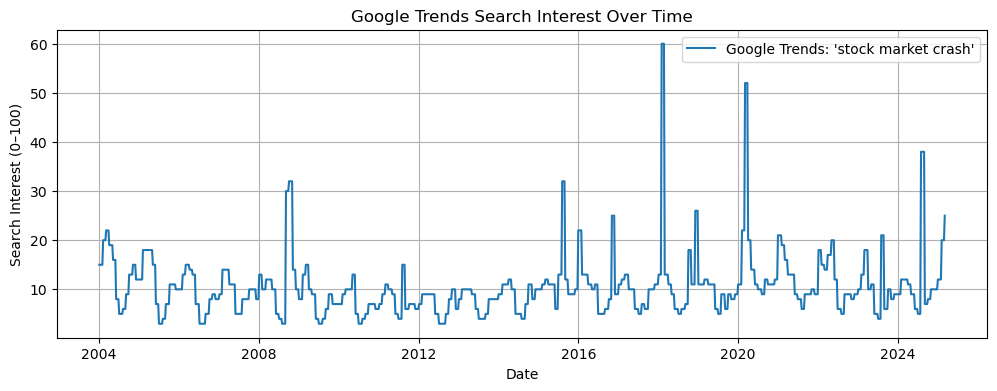

In [15]:
# Ensure date is the index for plotting
df_plot = df.copy()
df_plot.set_index("Date", inplace=True)

# Google Sentiment Over Time
plt.figure(figsize=(12, 4))
plt.plot(df_plot["Google_Sentiment_Index"], label="Google Trends: 'stock market crash'")
plt.title("Google Trends Search Interest Over Time")
plt.ylabel("Search Interest (0–100)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()

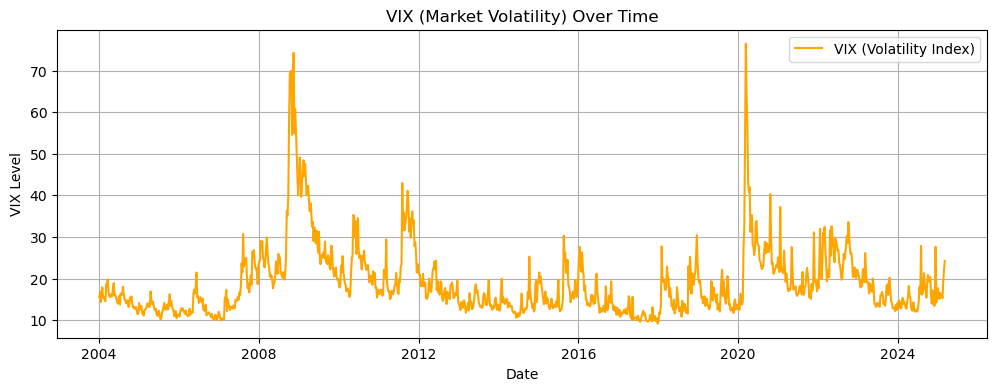

In [16]:
# Plot 2: VIX Over Time
plt.figure(figsize=(12, 4))
plt.plot(df_plot["VIX_Close"], color='orange', label="VIX (Volatility Index)")
plt.title("VIX (Market Volatility) Over Time")
plt.ylabel("VIX Level")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()

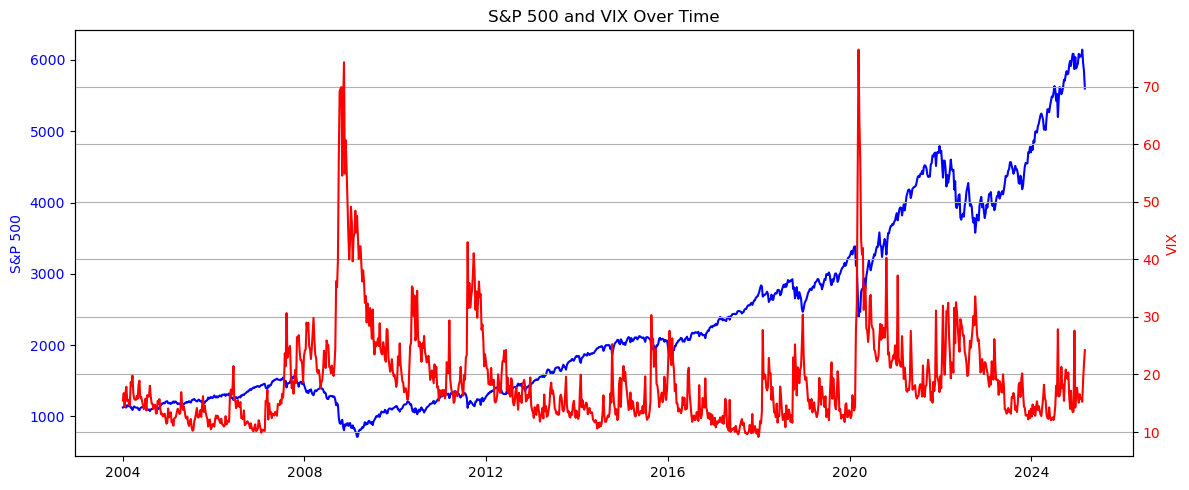

In [17]:
# Overlay S&P 500 with VIX
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_title("S&P 500 and VIX Over Time")
ax1.set_ylabel("S&P 500", color="blue")
ax1.plot(df_plot["Close"], color="blue", label="S&P 500")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.set_ylabel("VIX", color="red")
ax2.plot(df_plot["VIX_Close"], color="red", label="VIX")
ax2.tick_params(axis="y", labelcolor="red")

plt.grid(True)
fig.tight_layout()
plt.show()

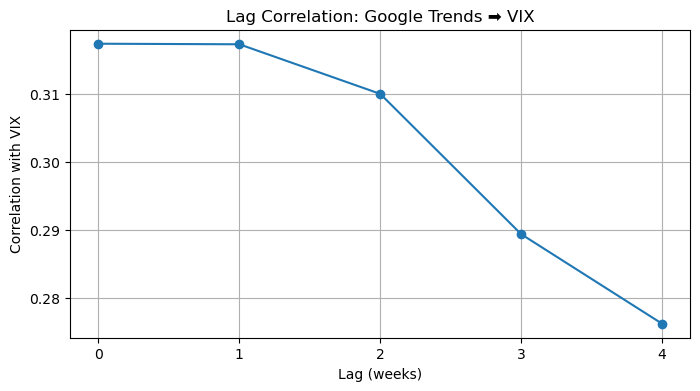

In [18]:
#Lag Correlation (Google Trends → VIX)
#Shifting Google Trends forward by 1 to 4 weeks
#Displaying how well it correlates with future VIX levels
lags = range(0, 5)  # 0 to 4 weeks ahead
correlations = []

for lag in lags:
    shifted = df["Google_Sentiment_Index"].shift(lag)
    corr = shifted.corr(df["VIX_Close"])
    correlations.append(corr)

# Plot lag correlations
plt.figure(figsize=(8, 4))
plt.plot(lags, correlations, marker='o')
plt.title("Lag Correlation: Google Trends ➡️ VIX")
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation with VIX")
plt.grid(True)
plt.xticks(lags)
plt.show()

In [19]:
# Prepare the data
granger_df = df[["VIX_Close", "Google_Sentiment_Index"]].dropna()

# Run Granger test: Does Google Sentiment "cause" VIX?
print("Granger Causality Test Results (max lag = 4)")
grangercausalitytests(granger_df, maxlag=4, verbose=True)

Granger Causality Test Results (max lag = 4)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.1618  , p=0.0233  , df_denom=1102, df_num=1
ssr based chi2 test:   chi2=5.1759  , p=0.0229  , df=1
likelihood ratio test: chi2=5.1638  , p=0.0231  , df=1
parameter F test:         F=5.1618  , p=0.0233  , df_denom=1102, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.3711  , p=0.0129  , df_denom=1099, df_num=2
ssr based chi2 test:   chi2=8.7819  , p=0.0124  , df=2
likelihood ratio test: chi2=8.7472  , p=0.0126  , df=2
parameter F test:         F=4.3711  , p=0.0129  , df_denom=1099, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.8742  , p=0.0023  , df_denom=1096, df_num=3
ssr based chi2 test:   chi2=14.7160 , p=0.0021  , df=3
likelihood ratio test: chi2=14.6187 , p=0.0022  , df=3
parameter F test:         F=4.8742  , p=0.0023  , df_denom=1096, df_num=3

Granger Causality
number of lags (no zero)

C:\Users\melny\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{1: ({'ssr_ftest': (5.1618139031402, 0.023280841021933413, 1102.0, 1),
   'ssr_chi2test': (5.1758660281033775, 0.022902752281930037, 1),
   'lrtest': (5.163781762841609, 0.023062627237273422, 1),
   'params_ftest': (5.161813903140209, 0.023280841021933413, 1102.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (4.37106391938743, 0.012858239201095658, 1099.0, 2),
   'ssr_chi2test': (8.781900940862096, 0.012388948293594144, 2),
   'lrtest': (8.747156726335561, 0.012606050735765758, 2),
   'params_ftest': (4.371063919387392, 0.012858239201095658, 1099.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (4.8742129073130505, 0.0022629784176621524, 1096.0, 3),
   'ssr_chi2test': (14.71603148749898, 0.002076125165413066, 3),
   'lrtest': (14.618726666062685, 0.0021732379883054593, 3),
   'params_ftest': (4.874212907312958, 0.0022629784176624395, 1096.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
  

In [20]:
# 🎯 Target variable
df["Target_NextWeekDrop"] = (df["SP500_Returns"].shift(-1) < 0).astype(int)

In [21]:
# 🚿 Drop NA
df_model = df.dropna(subset=[
    "Mood_Index", "Mood_Index_Lag1",
    "SP500_Returns_Lag1", "VIX_Change_Lag1",
    "Google_Trend_Lag1", "Unemployment_Lag1",
    "Target_NextWeekDrop"
]).copy()

In [22]:
# ✨ Features
features = [
    "Mood_Index", "Mood_Index_Lag1",
    "SP500_Returns_Lag1", "VIX_Change_Lag1",
    "Google_Trend_Lag1", "Unemployment_Lag1"
]

X = df_model[features]
y = df_model["Target_NextWeekDrop"]

In [23]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

In [24]:
# Define hyperparameters to tune
params = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'scale_pos_weight': [1, 1.5, 2]  # handles class imbalance
}

# Initial model setup
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Grid search with F1-score to optimize drop detection
grid = GridSearchCV(
    xgb,
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train with hyperparameter tuning
grid.fit(X_train, y_train)

# Best model from search
best_model = grid.best_estimator_
print("✅ Best Parameters:", grid.best_params_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
✅ Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': 2, 'subsample': 1.0}


C:\Users\melny\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [12:26:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [25]:
# Predict probabilities
y_probs = best_model.predict_proba(X_test)[:, 1]

# Try multiple thresholds
thresholds = [0.5, 0.47, 0.45, 0.42, 0.4, 0.38, 0.35]

print("🔍 Threshold Testing Results\n")
for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    conf = confusion_matrix(y_test, y_pred)

    print(f"Threshold = {t}")
    print(f"  F1 Score     (class 1): {f1:.3f}")
    print(f"  Recall       (class 1): {recall:.3f}")
    print(f"  Precision    (class 1): {precision:.3f}")
    print(f"  Confusion Matrix:\n{conf}")
    print("-" * 40)


🔍 Threshold Testing Results

Threshold = 0.5
  F1 Score     (class 1): 0.457
  Recall       (class 1): 0.578
  Precision    (class 1): 0.378
  Confusion Matrix:
[[ 82 122]
 [ 54  74]]
----------------------------------------
Threshold = 0.47
  F1 Score     (class 1): 0.490
  Recall       (class 1): 0.680
  Precision    (class 1): 0.383
  Confusion Matrix:
[[ 64 140]
 [ 41  87]]
----------------------------------------
Threshold = 0.45
  F1 Score     (class 1): 0.497
  Recall       (class 1): 0.719
  Precision    (class 1): 0.380
  Confusion Matrix:
[[ 54 150]
 [ 36  92]]
----------------------------------------
Threshold = 0.42
  F1 Score     (class 1): 0.515
  Recall       (class 1): 0.789
  Precision    (class 1): 0.383
  Confusion Matrix:
[[ 41 163]
 [ 27 101]]
----------------------------------------
Threshold = 0.4
  F1 Score     (class 1): 0.534
  Recall       (class 1): 0.859
  Precision    (class 1): 0.387
  Confusion Matrix:
[[ 30 174]
 [ 18 110]]
-----------------------------

In [26]:
# ✅ Use best threshold found (based on F1-Score)
best_threshold = 0.38
y_pred = (y_probs > best_threshold).astype(int)

# 📊 Final evaluation
print("🔍 Final Evaluation (threshold = 0.38):")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


🔍 Final Evaluation (threshold = 0.38):
[[ 22 182]
 [ 12 116]]
              precision    recall  f1-score   support

           0      0.647     0.108     0.185       204
           1      0.389     0.906     0.545       128

    accuracy                          0.416       332
   macro avg      0.518     0.507     0.365       332
weighted avg      0.548     0.416     0.324       332



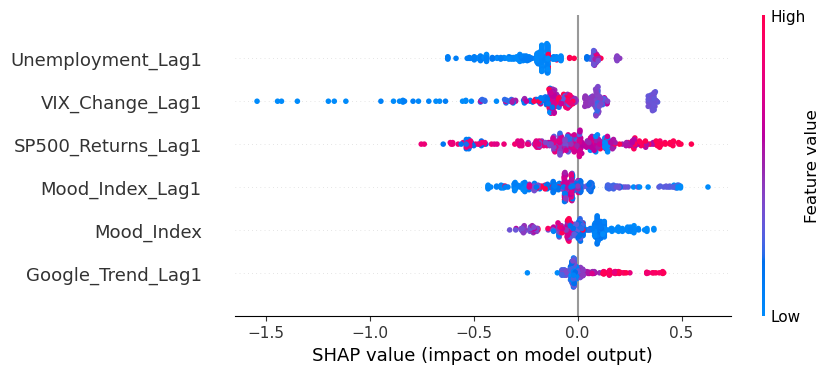

In [27]:
# ⚙️ Build SHAP explainer
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# 📊 Show summary
shap.plots.beeswarm(shap_values)


In [28]:
joblib.dump(best_model, "final_model_xgb.pkl")

['final_model_xgb.pkl']